#### Dataset

In [1]:
# Social_Network_Ads.csv
# location: https://mitu.co.in/dataset

#### import the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### import the dataset

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')

In [4]:
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [5]:
df.shape

(400, 5)

In [6]:
# check for missing values
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

#### separate input and output data

In [7]:
# input data
x = df[['Age','EstimatedSalary']]

# output data
y = df['Purchased']

In [8]:
x.describe()

,Age,EstimatedSalary
count,400.000000,400.000000
mean,37.655000,69742.500000
std,10.482877,34096.960282
min,18.000000,15000.000000
25%,29.750000,43000.000000
50%,37.000000,70000.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [9]:
np.unique(y)

array([0, 1])

In [10]:
y.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

/home/aditya/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/aditya/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/aditya/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


<Axes: xlabel='Purchased', ylabel='count'>

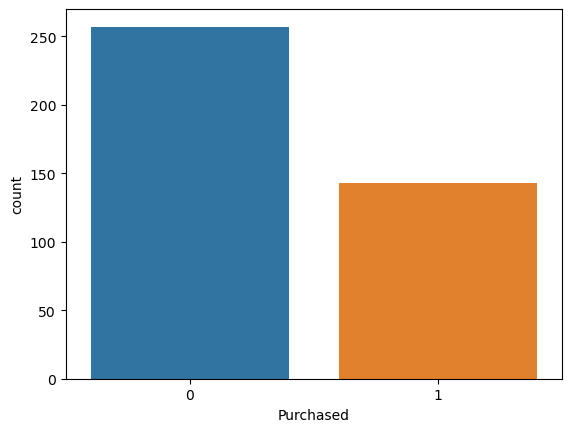

In [11]:
import seaborn as sns
sns.countplot(x = y)

#### visualize the data

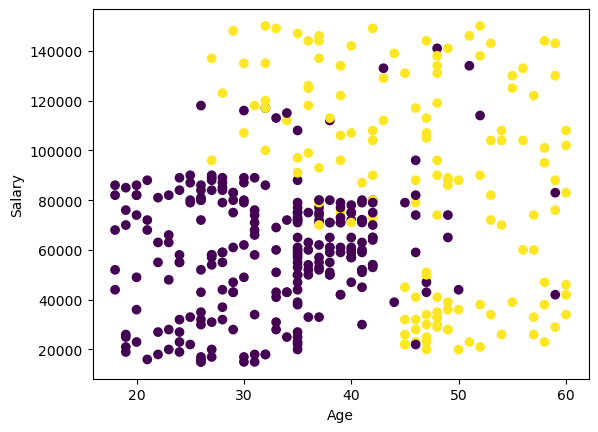

In [12]:
plt.xlabel('Age')
plt.ylabel('Salary')
plt.scatter(x['Age'], x['EstimatedSalary'], c = y)

In [13]:
import warnings
warnings.filterwarnings('ignore')

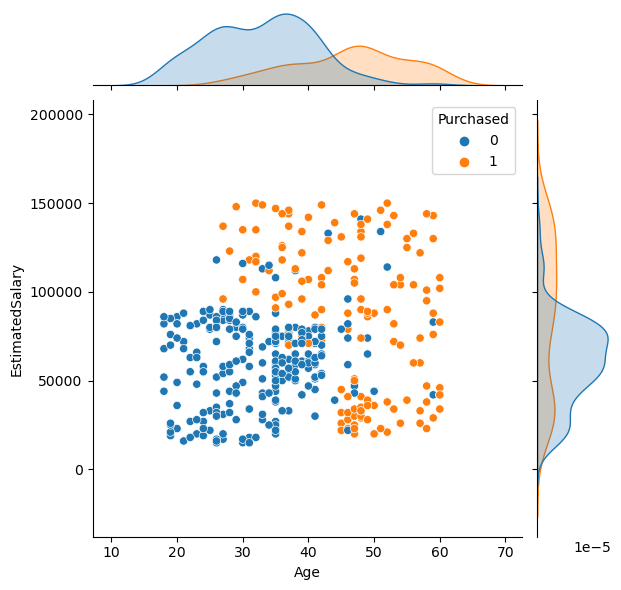

In [14]:
sns.jointplot(x = 'Age', y = 'EstimatedSalary',
              hue = 'Purchased', data = df);

In [15]:
x

,Age,EstimatedSalary
0,19.0,19000.0
1,35.0,20000.0
2,26.0,43000.0
3,27.0,57000.0
4,19.0,76000.0
...,...,...
395,46.0,41000.0
396,51.0,23000.0
397,50.0,20000.0
398,36.0,33000.0


#### feature scaling

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [17]:
pd.DataFrame(x_scaled).describe()

,0,1
count,400.000000,400.000000
mean,0.467976,0.405500
std,0.249592,0.252570
min,0.000000,0.000000
25%,0.279762,0.207407
50%,0.452381,0.407407
75%,0.666667,0.540741
max,1.000000,1.000000


#### cross validation

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y,
                                                   random_state=0,
                                                   test_size= 0.25)

In [20]:
x_train.shape

(300, 2)

In [21]:
x_test.shape

(100, 2)

#### Build the model

In [23]:
# import the classes

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [24]:
# create the objects
clf_log = LogisticRegression(random_state=0)
clf_dt = DecisionTreeClassifier(random_state=0)
clf_knn = KNeighborsClassifier(n_neighbors= 5)
clf_nb = GaussianNB()
clf_svm = SVC(kernel= 'rbf', random_state=0)

In [25]:
# Train the models
clf_log.fit(x_train, y_train)
clf_dt.fit(x_train, y_train)
clf_knn.fit(x_train, y_train)
clf_nb.fit(x_train, y_train)
clf_svm.fit(x_train, y_train)

SVC(random_state=0)

### Stacking Classification

In [26]:
from sklearn.ensemble import StackingClassifier

In [41]:
stack = StackingClassifier(estimators= [('DT',clf_dt),
                                         ('knn',clf_knn), 
                                         ('NB',clf_nb),
                                         ('SVC',clf_svm)], final_estimator= clf_log)

In [42]:
stack.fit(x_train, y_train)

StackingClassifier(estimators=[('DT', DecisionTreeClassifier(random_state=0)),
                               ('knn', KNeighborsClassifier()),
                               ('NB', GaussianNB()),
                               ('SVC', SVC(random_state=0))],
                   final_estimator=LogisticRegression(random_state=0))

In [43]:
y_pred = stack.predict(x_test)

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.93